# Anomaly Benchmark
 
**Scope:** Controlled fault injection and anomaly-detection benchmark for synthetic Aido Rover telemetry  
**Input:** `data/w03_rover_5units_1day/`, generated from the Week 3 telemetry generator  
**Methods:** Isolation Forest, One-Class SVM, Local Outlier Factor, LSTM Autoencoder  
**Evaluation:** Precision, recall, F1, AUROC by fault type, across 10 seeded train/test splits, plus paired Wilcoxon signed-rank tests on AUROC differences

---

## Benchmark Design

This notebook starts from the clean Week 3 synthetic Rover telemetry sample and injects five controlled fault patterns only into held-out test blocks:

1. `motor_stall`
2. `gradual_sensor_drift`
3. `accelerated_battery_degradation`
4. `gps_jitter_spoofing`
5. `intermittent_software_hang`

The benchmark uses unsupervised anomaly detection. Models train only on clean training windows, then score test windows containing both clean windows and controlled injected faults.

---

## Leakage Controls

1. **Time-block split before injection:** each split selects held-out robot-hour blocks first.
2. **Faults injected only into test blocks:** training blocks remain clean.
3. **Scaler fit only on clean training windows:** no statistics from test windows are used for normalization.
4. **Rolling features reset at robot-hour boundaries:** rolling windows do not cross train/test block boundaries.

This makes the comparison closer to a realistic deployment setting: the model learns normal Rover telemetry, then sees controlled fault patterns during held-out operation.


In [1]:
import json
import math
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

from scipy.stats import wilcoxon

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    TORCH_IMPORT_ERROR = e

print("Torch available:", TORCH_AVAILABLE)
if TORCH_AVAILABLE:
    torch.set_num_threads(1)
    print("Torch version:", torch.__version__)


Torch available: True
Torch version: 2.13.0


## 1. Configuration

The full requirement is **10 seeded train/test splits**. `N_SPLITS` is set to 10 by default.


In [2]:
# -----------------------------
# Core benchmark configuration
# -----------------------------

DATA_DIR = Path("../data/w03_rover_5units_1day")
MANIFEST_PATH = DATA_DIR / "manifest.json"
SANDBOX_DIR = Path("/mnt/data")

WINDOW_SECONDS = 60
TEST_HOURS_PER_SPLIT = 8
FAULT_EVENTS_PER_TYPE = 3

N_SPLITS = 10
SPLIT_SEEDS = [20260400 + i for i in range(N_SPLITS)]

CONTAMINATION = 0.03
THRESHOLD_QUANTILE = 1.0 - CONTAMINATION

# LSTM autoencoder settings. These are intentionally modest so the notebook can run on a laptop CPU.
LSTM_SEQUENCE_LENGTH = 8
LSTM_EPOCHS = 1
LSTM_BATCH_SIZE = 256
LSTM_HIDDEN_DIM = 16
LSTM_LATENT_DIM = 8
LSTM_MAX_TRAIN_SEQUENCES = 1000

RESULTS_DIR = Path("../results/w04_anomaly_benchmark")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FAULT_TYPES = [
    "motor_stall",
    "gradual_sensor_drift",
    "accelerated_battery_degradation",
    "gps_jitter_spoofing",
    "intermittent_software_hang",
]

RAW_COLS = [
    "schema_version", "timestamp", "elapsed_s", "day_index",
    "robot_id", "robot_index", "mission_mode", "terrain", "location_zone",
    "speed_mps",
    "battery_soc_pct", "battery_voltage_v", "motor_temp_c",
    "motor_current_fl_a", "motor_current_fr_a", "motor_current_rl_a", "motor_current_rr_a",
    "imu_accel_x_mps2", "imu_accel_y_mps2", "imu_accel_z_mps2",
    "imu_gyro_x_rps", "imu_gyro_y_rps", "imu_gyro_z_rps",
    "wifi_rssi_dbm", "gps_fix_quality", "gps_hdop", "gps_num_sats",
    "x_m", "y_m",
    "task_success_probability", "task_success_flag",
    "benign_noise_flag", "missingness_flag", "is_charging",
]

print("Configured splits:", SPLIT_SEEDS)
print("Results directory:", RESULTS_DIR)


Configured splits: [20260400, 20260401, 20260402, 20260403, 20260404, 20260405, 20260406, 20260407, 20260408, 20260409]
Results directory: ../results/w04_anomaly_benchmark


In [3]:
def find_telemetry_files():
    # Find Week 3 telemetry partitions.
    candidates = []

    if DATA_DIR.exists():
        candidates = sorted(DATA_DIR.glob("**/telemetry.csv.gz"))

    if not candidates and SANDBOX_DIR.exists():
        candidates = sorted(SANDBOX_DIR.glob("telemetry*.gz"))

    if not candidates:
        candidates = sorted(Path(".").glob("telemetry*.gz"))

    # Avoid duplicate old uploads by keeping one partition per robot_id if possible.
    selected = []
    seen_robot_ids = set()

    for path in candidates:
        try:
            probe = pd.read_csv(path, usecols=["robot_id"], nrows=5)
            rid = str(probe["robot_id"].iloc[0])
        except Exception:
            rid = path.name

        if rid not in seen_robot_ids:
            seen_robot_ids.add(rid)
            selected.append(path)

    return selected


def load_manifest():
    # Load manifest if available.
    manifest_candidates = [
        MANIFEST_PATH,
        Path("manifest.json"),
        SANDBOX_DIR / "manifest.json",
        SANDBOX_DIR / "manifest(1).json",
    ]
    for path in manifest_candidates:
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f), path
    return None, None


manifest, manifest_source = load_manifest()
telemetry_files = find_telemetry_files()

print("Manifest source:", manifest_source)
print("Telemetry files found:", len(telemetry_files))
for p in telemetry_files:
    print(" -", p)

if manifest is not None:
    print("\nManifest estimate:")
    display(pd.DataFrame([manifest.get("estimate", {})]))

if len(telemetry_files) == 0:
    raise FileNotFoundError("No telemetry.csv.gz files found. Check DATA_DIR or upload the Week 3 sample partitions.")


Manifest source: ../data/w03_rover_5units_1day/manifest.json
Telemetry files found: 5
 - ../data/w03_rover_5units_1day/robot_id=AR-001/day=000/telemetry.csv.gz
 - ../data/w03_rover_5units_1day/robot_id=AR-002/day=000/telemetry.csv.gz
 - ../data/w03_rover_5units_1day/robot_id=AR-003/day=000/telemetry.csv.gz
 - ../data/w03_rover_5units_1day/robot_id=AR-004/day=000/telemetry.csv.gz
 - ../data/w03_rover_5units_1day/robot_id=AR-005/day=000/telemetry.csv.gz

Manifest estimate:


,fleet_size,format,freq_hz,horizon_days,output_dir,partitions,ticks_per_robot,total_rows
0,5,csv.gz,1.0,1.0,data/w03_rover_5units_1day,5,86400,432000


## 2. Load Clean Week 3 Telemetry

The input data is treated as the clean baseline. Controlled faults are injected later and only inside held-out test blocks.


In [4]:
def load_clean_telemetry(paths):
    # Load the clean Week 3 telemetry partitions.
    frames = []

    for path in paths:
        df_part = pd.read_csv(path, usecols=lambda c: c in RAW_COLS)
        frames.append(df_part)

    df = pd.concat(frames, ignore_index=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.sort_values(["robot_id", "elapsed_s"]).reset_index(drop=True)

    # Make sure expected numeric columns are numeric.
    for col in df.columns:
        if col not in ["schema_version", "timestamp", "robot_id", "mission_mode", "terrain", "location_zone"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


clean_df = load_clean_telemetry(telemetry_files)

print("Clean telemetry shape:", clean_df.shape)
print("Robots:", sorted(clean_df["robot_id"].unique()))
print("Time range:", clean_df["timestamp"].min(), "to", clean_df["timestamp"].max())
display(clean_df.head())
display(clean_df[["speed_mps", "battery_soc_pct", "battery_voltage_v", "wifi_rssi_dbm", "gps_fix_quality"]].describe().T)


Clean telemetry shape: (432000, 34)
Robots: ['AR-001', 'AR-002', 'AR-003', 'AR-004', 'AR-005']
Time range: 2026-07-01 00:00:00+00:00 to 2026-07-01 23:59:59+00:00


,schema_version,timestamp,elapsed_s,day_index,robot_id,robot_index,mission_mode,terrain,location_zone,x_m,y_m,speed_mps,imu_accel_x_mps2,imu_accel_y_mps2,imu_accel_z_mps2,imu_gyro_x_rps,imu_gyro_y_rps,imu_gyro_z_rps,motor_current_fl_a,motor_current_fr_a,motor_current_rl_a,motor_current_rr_a,motor_temp_c,battery_voltage_v,battery_soc_pct,is_charging,wifi_rssi_dbm,gps_fix_quality,gps_hdop,gps_num_sats,task_success_probability,task_success_flag,benign_noise_flag,missingness_flag
0,w03_rover_telemetry_v1,2026-07-01 00:00:00+00:00,0.0,0,AR-001,0,incident_response,asphalt,base_area,500.000000,500.000000,1.436392,0.053326,0.041431,9.802603,-0.012392,-0.007891,-0.015293,17.826899,17.640864,17.890293,17.611667,35.139522,50.173127,94.950267,0,-44.683029,5.0,0.681922,18.0,0.984,1,0,0
1,w03_rover_telemetry_v1,2026-07-01 00:00:01+00:00,1.0,0,AR-001,0,incident_response,asphalt,base_area,500.314159,500.314159,1.516644,0.117964,-0.015616,9.741452,-0.011331,0.003758,0.001673,18.714663,18.522695,18.818583,18.718360,36.566188,50.163606,95.086060,0,-45.728823,5.0,0.665504,18.0,0.984,1,0,0
2,w03_rover_telemetry_v1,2026-07-01 00:00:02+00:00,2.0,0,AR-001,0,incident_response,asphalt,base_area,500.628317,500.628316,1.559057,0.045394,0.070653,9.849124,0.002368,-0.009645,0.018011,19.619755,18.967178,19.192554,18.979462,37.088039,50.123560,94.843689,0,-45.859757,5.0,0.559834,17.0,0.984,0,0,0
3,w03_rover_telemetry_v1,2026-07-01 00:00:03+00:00,3.0,0,AR-001,0,incident_response,asphalt,base_area,500.942473,500.942470,1.481559,0.051724,0.008286,9.732263,0.009417,-0.003002,0.024272,18.666803,17.796062,18.477000,17.833158,36.656356,50.145381,94.807189,0,-48.070381,5.0,0.469634,17.0,0.984,1,0,0
4,w03_rover_telemetry_v1,2026-07-01 00:00:04+00:00,4.0,0,AR-001,0,incident_response,asphalt,base_area,501.256627,501.256619,1.527396,-0.012727,0.065078,9.844583,0.006906,0.018024,0.042963,19.588383,18.422224,19.616996,18.139045,37.369795,50.143287,94.962232,0,-48.308189,5.0,0.469417,17.0,0.984,1,0,0


,count,mean,std,min,25%,50%,75%,max
speed_mps,432000.0,0.650157,0.367282,0.000000,0.484544,0.721033,0.869957,1.747691
battery_soc_pct,432000.0,55.302078,23.825119,9.697438,35.505094,57.304350,75.523643,95.366002
battery_voltage_v,432000.0,46.058980,2.707898,40.594735,43.902558,46.225921,48.305436,51.951247
wifi_rssi_dbm,431708.0,-64.944068,12.150099,-108.920154,-73.448613,-64.898691,-55.789614,-19.616961
gps_fix_quality,431708.0,4.142223,0.738009,2.000000,4.000000,4.000000,5.000000,5.000000


## 3. Fault Injection

Faults are injected into held-out test hours only. Each injected event is written into a fault ledger with `fault_id`, `fault_type`, `robot_id`, `start_s`, `end_s`, `duration_s`, `severity`, and `notes`.

| Fault | Injection logic |
|---|---|
| Motor stall | Speed collapses, one drive current spikes, motor temperature rises, task success drops |
| Gradual sensor drift | IMU acceleration and gyro drift gradually over the event window |
| Accelerated battery degradation | SoC and voltage decline faster than expected during operation |
| GPS jitter spoofing-like | Position jumps, HDOP degrades, fix quality becomes unstable |
| Intermittent software hang | Selected telemetry channels freeze in repeated blocks, with missingness and task-success impact |


In [5]:
def select_test_hours(seed, n_hours=TEST_HOURS_PER_SPLIT):
    # Select held-out hour blocks for one split.
    rng = np.random.default_rng(seed)
    hours = np.arange(24)
    return set(rng.choice(hours, size=n_hours, replace=False).tolist())


def _sample_non_overlapping_event(rng, robots, test_hours, used_intervals, duration_range=(240, 900)):
    # Sample one non-overlapping event interval inside the held-out hours.
    for _ in range(500):
        robot = str(rng.choice(robots))
        hour = int(rng.choice(list(test_hours)))
        duration = int(rng.integers(duration_range[0], duration_range[1] + 1))
        start = int(hour * 3600 + rng.integers(0, max(1, 3600 - duration)))
        end = start + duration

        overlap = False
        for used_robot, used_start, used_end in used_intervals:
            if used_robot == robot and not (end < used_start - 300 or start > used_end + 300):
                overlap = True
                break

        if not overlap:
            return robot, start, end, duration

    raise RuntimeError("Could not sample a non-overlapping fault interval.")


def inject_controlled_faults(df, seed, test_hours, events_per_type=FAULT_EVENTS_PER_TYPE):
    # Inject five controlled fault types into test-hour blocks only.
    rng = np.random.default_rng(seed)

    out = df.copy(deep=True)
    out["hour_block"] = (out["elapsed_s"] // 3600).astype(int)
    out["fault_type"] = "clean"
    out["fault_id"] = "clean"
    out["fault_severity"] = 0.0

    robots = np.array(sorted(out["robot_id"].unique()))
    used_intervals = []
    ledger = []

    for fault_type in FAULT_TYPES:
        for event_idx in range(events_per_type):
            robot, start_s, end_s, duration_s = _sample_non_overlapping_event(
                rng=rng,
                robots=robots,
                test_hours=test_hours,
                used_intervals=used_intervals,
            )
            used_intervals.append((robot, start_s, end_s))

            mask = (
                (out["robot_id"] == robot)
                & (out["elapsed_s"] >= start_s)
                & (out["elapsed_s"] < end_s)
                & (out["hour_block"].isin(test_hours))
            )
            idx = np.flatnonzero(mask.to_numpy())
            if idx.size == 0:
                continue

            severity = float(rng.uniform(0.60, 1.00))
            fault_id = f"{fault_type}_seed{seed}_event{event_idx:02d}"

            out.loc[idx, "fault_type"] = fault_type
            out.loc[idx, "fault_id"] = fault_id
            out.loc[idx, "fault_severity"] = severity

            rel = np.linspace(0.0, 1.0, idx.size)

            if fault_type == "motor_stall":
                stalled_motor = str(rng.choice([
                    "motor_current_fl_a", "motor_current_fr_a",
                    "motor_current_rl_a", "motor_current_rr_a",
                ]))
                out.loc[idx, "speed_mps"] = out.loc[idx, "speed_mps"].to_numpy() * (0.02 + 0.05 * (1.0 - severity))
                out.loc[idx, stalled_motor] = np.clip(
                    out.loc[idx, stalled_motor].to_numpy() + 25.0 + 20.0 * severity,
                    0.0,
                    60.0,
                )
                out.loc[idx, "motor_temp_c"] = out.loc[idx, "motor_temp_c"].to_numpy() + 5.0 + 10.0 * severity * rel
                out.loc[idx, "task_success_flag"] = 0
                notes = f"Stalled drive: {stalled_motor}; speed collapse, high current, rising thermal load."

            elif fault_type == "gradual_sensor_drift":
                out.loc[idx, "imu_accel_z_mps2"] = out.loc[idx, "imu_accel_z_mps2"].to_numpy() + severity * (0.5 + 1.2 * rel)
                out.loc[idx, "imu_gyro_z_rps"] = out.loc[idx, "imu_gyro_z_rps"].to_numpy() + severity * (0.02 + 0.08 * rel)
                notes = "Ramp drift injected into IMU accel_z and gyro_z to mimic gradual calibration drift."

            elif fault_type == "accelerated_battery_degradation":
                soc_drop = (5.0 + 15.0 * severity) * rel
                out.loc[idx, "battery_soc_pct"] = np.maximum(out.loc[idx, "battery_soc_pct"].to_numpy() - soc_drop, 0.0)
                out.loc[idx, "battery_voltage_v"] = out.loc[idx, "battery_voltage_v"].to_numpy() - (0.8 + 1.2 * severity * rel)
                out.loc[idx, "task_success_probability"] = np.minimum(
                    out.loc[idx, "task_success_probability"].to_numpy(),
                    0.97 - 0.20 * severity * rel,
                )
                notes = "Accelerated SoC drain and voltage sag injected during held-out operation."

            elif fault_type == "gps_jitter_spoofing":
                jumps = rng.normal(0.0, 25.0 + 75.0 * severity, size=(idx.size, 2)).cumsum(axis=0)
                out.loc[idx, "x_m"] = out.loc[idx, "x_m"].to_numpy() + jumps[:, 0]
                out.loc[idx, "y_m"] = out.loc[idx, "y_m"].to_numpy() + jumps[:, 1]
                out.loc[idx, "gps_hdop"] = out.loc[idx, "gps_hdop"].to_numpy() + 1.0 + 3.0 * severity * rng.random(idx.size)
                out.loc[idx, "gps_fix_quality"] = np.clip(
                    out.loc[idx, "gps_fix_quality"].to_numpy() + rng.choice([-2, -1, 1, 2], size=idx.size),
                    0,
                    5,
                )
                notes = "Spoofing-like GPS jitter injected through position jumps, HDOP degradation, and unstable fix quality."

            elif fault_type == "intermittent_software_hang":
                freeze_cols = [
                    "speed_mps", "battery_soc_pct", "battery_voltage_v",
                    "motor_current_fl_a", "motor_current_fr_a", "motor_current_rl_a", "motor_current_rr_a",
                    "imu_accel_x_mps2", "imu_accel_y_mps2", "imu_accel_z_mps2",
                    "imu_gyro_x_rps", "imu_gyro_y_rps", "imu_gyro_z_rps",
                    "wifi_rssi_dbm", "gps_fix_quality", "gps_hdop", "x_m", "y_m",
                ]

                hang = np.zeros(idx.size, dtype=bool)
                pos = 0
                while pos < idx.size:
                    block = int(rng.integers(15, 60))
                    gap = int(rng.integers(30, 180))
                    hang[pos:pos + block] = True
                    pos += block + gap

                hang_idx = idx[hang]
                if hang_idx.size > 0:
                    block_ids = np.cumsum(np.r_[True, np.diff(hang_idx) > 1])
                    for block_id in np.unique(block_ids):
                        rows = hang_idx[block_ids == block_id]
                        first = rows[0]
                        out.loc[rows, freeze_cols] = out.loc[first, freeze_cols].to_numpy()

                    out.loc[hang_idx, "task_success_flag"] = 0
                    out.loc[hang_idx, "missingness_flag"] = 1

                notes = "Repeated telemetry freezes injected to mimic intermittent software hang or stale-packet behavior."

            else:
                notes = ""

            ledger.append({
                "split_seed": seed,
                "fault_id": fault_id,
                "fault_type": fault_type,
                "robot_id": robot,
                "start_s": start_s,
                "end_s": end_s,
                "duration_s": duration_s,
                "severity": severity,
                "notes": notes,
            })

    out["is_fault"] = (out["fault_type"] != "clean").astype(int)
    ledger_df = pd.DataFrame(ledger)

    # Sanity check: no injected faults outside test hours.
    leaked_faults = out.loc[(out["is_fault"] == 1) & (~out["hour_block"].isin(test_hours))]
    if len(leaked_faults) > 0:
        raise AssertionError("Fault injection leakage detected outside held-out test hours.")

    return out, ledger_df


## 4. Feature Engineering and Windowization

The benchmark operates at **one-minute window level**. Raw 1 Hz telemetry is the source data, and window aggregation makes the benchmark practical and closer to operational monitoring: a real fleet dashboard would rarely alert on one isolated second without context.

Features include propulsion load, drive imbalance, voltage-versus-SoC consistency, IMU motion norms, GPS/WiFi consistency, short rolling statistics within robot-hour block, and inter-unit z-scores at the same window.


In [6]:
RAW_FEATURE_AGG_COLS = [
    "speed_mps",
    "battery_soc_pct",
    "battery_voltage_v",
    "motor_temp_c",
    "motor_current_fl_a", "motor_current_fr_a", "motor_current_rl_a", "motor_current_rr_a",
    "imu_accel_x_mps2", "imu_accel_y_mps2", "imu_accel_z_mps2",
    "imu_gyro_x_rps", "imu_gyro_y_rps", "imu_gyro_z_rps",
    "wifi_rssi_dbm",
    "gps_fix_quality", "gps_hdop", "gps_num_sats",
    "x_m", "y_m",
    "task_success_flag",
    "missingness_flag",
]


def build_window_features(df, window_seconds=WINDOW_SECONDS):
    # Aggregate raw 1 Hz telemetry into one-minute windows and engineer features.
    work = df.copy()
    work["window_id"] = (work["elapsed_s"] // window_seconds).astype(int)
    work["hour_block"] = (work["elapsed_s"] // 3600).astype(int)

    agg_spec = {}
    for col in RAW_FEATURE_AGG_COLS:
        if col in work.columns:
            agg_spec[col] = ["mean", "std", "min", "max"]

    win = work.groupby(["robot_id", "window_id"], sort=True).agg(agg_spec)
    win.columns = [f"{a}__{b}" for a, b in win.columns]
    win = win.reset_index()

    label = work.groupby(["robot_id", "window_id"], sort=True).agg(
        hour_block=("hour_block", "first"),
        is_fault=("is_fault", "max"),
        fault_type=("fault_type", lambda s: s[s != "clean"].mode().iloc[0] if (s != "clean").any() else "clean"),
        fault_id=("fault_id", lambda s: s[s != "clean"].mode().iloc[0] if (s != "clean").any() else "clean"),
        fault_severity=("fault_severity", "max"),
    ).reset_index()

    win = win.merge(label, on=["robot_id", "window_id"], how="left")

    eps = 1e-6
    motor_means = [
        "motor_current_fl_a__mean",
        "motor_current_fr_a__mean",
        "motor_current_rl_a__mean",
        "motor_current_rr_a__mean",
    ]

    win["motor_current_mean_a"] = win[motor_means].mean(axis=1)
    win["motor_side_imbalance_ratio"] = (
        (win[["motor_current_fl_a__mean", "motor_current_rl_a__mean"]].mean(axis=1)
         - win[["motor_current_fr_a__mean", "motor_current_rr_a__mean"]].mean(axis=1)).abs()
        / (win["motor_current_mean_a"] + eps)
    )
    win["motor_front_rear_ratio"] = (
        win[["motor_current_fl_a__mean", "motor_current_fr_a__mean"]].mean(axis=1)
        / (win[["motor_current_rl_a__mean", "motor_current_rr_a__mean"]].mean(axis=1) + eps)
    )
    win["motor_temp_current_ratio"] = win["motor_temp_c__mean"] / (win["motor_current_mean_a"] + eps)
    win["battery_voltage_soc_residual"] = win["battery_voltage_v__mean"] - (40.0 + 11.2 * win["battery_soc_pct__mean"] / 100.0)

    win["imu_accel_norm_mps2"] = np.sqrt(
        win["imu_accel_x_mps2__mean"] ** 2
        + win["imu_accel_y_mps2__mean"] ** 2
        + win["imu_accel_z_mps2__mean"] ** 2
    )
    win["imu_gyro_norm_rps"] = np.sqrt(
        win["imu_gyro_x_rps__mean"] ** 2
        + win["imu_gyro_y_rps__mean"] ** 2
        + win["imu_gyro_z_rps__mean"] ** 2
    )
    win["accel_gravity_residual_abs"] = (win["imu_accel_norm_mps2"] - 9.81).abs()
    win["speed_current_efficiency"] = win["speed_mps__mean"] / (win["motor_current_mean_a"] + eps)
    win["gps_hdop_fix_ratio"] = win["gps_hdop__mean"] / (win["gps_fix_quality__mean"] + 1.0)
    win["gps_wifi_consistency_score"] = (
        0.5 * (win["gps_fix_quality__mean"] / 5.0)
        + 0.5 * np.clip((win["wifi_rssi_dbm__mean"] + 100.0) / 65.0, 0.0, 1.0)
    )

    # Rolling features reset at robot-hour level.
    group = win.groupby(["robot_id", "hour_block"], sort=False)

    win["motor_current_5m_mean_a"] = group["motor_current_mean_a"].transform(lambda s: s.rolling(5, min_periods=2).mean())
    win["motor_current_5m_std_a"] = group["motor_current_mean_a"].transform(lambda s: s.rolling(5, min_periods=2).std())
    win["battery_soc_5m_slope_pct_per_min"] = group["battery_soc_pct__mean"].transform(lambda s: (s - s.shift(5)) / 5.0)
    win["wifi_rssi_5m_mean_dbm"] = group["wifi_rssi_dbm__mean"].transform(lambda s: s.rolling(5, min_periods=2).mean())
    win["wifi_rssi_5m_std_db"] = group["wifi_rssi_dbm__mean"].transform(lambda s: s.rolling(5, min_periods=2).std())
    win["imu_vibration_5m_rms"] = group["accel_gravity_residual_abs"].transform(lambda s: np.sqrt((s ** 2).rolling(5, min_periods=2).mean()))
    win["missingness_5m_rate"] = group["missingness_flag__mean"].transform(lambda s: s.rolling(5, min_periods=2).mean())

    # Inter-unit z-scores within each window_id.
    for source_col, out_col in [
        ("battery_soc_pct__mean", "battery_soc_interunit_z"),
        ("motor_current_mean_a", "motor_current_interunit_z"),
        ("wifi_rssi_dbm__mean", "wifi_rssi_interunit_z"),
    ]:
        mean_t = win.groupby("window_id")[source_col].transform("mean")
        std_t = win.groupby("window_id")[source_col].transform("std").replace(0.0, np.nan)
        win[out_col] = (win[source_col] - mean_t) / std_t

    win = win.replace([np.inf, -np.inf], np.nan)

    return win


BASE_FEATURE_COLS = [
    "speed_mps__mean", "speed_mps__std", "speed_mps__min",
    "battery_soc_pct__mean", "battery_soc_pct__std",
    "battery_voltage_v__mean", "battery_voltage_v__std",
    "motor_temp_c__mean",
    "wifi_rssi_dbm__mean", "wifi_rssi_dbm__std",
    "gps_fix_quality__mean", "gps_hdop__mean", "gps_num_sats__mean",
    "task_success_flag__mean", "missingness_flag__mean",
    "motor_current_mean_a",
    "motor_side_imbalance_ratio",
    "motor_front_rear_ratio",
    "motor_temp_current_ratio",
    "battery_voltage_soc_residual",
    "imu_accel_norm_mps2",
    "imu_gyro_norm_rps",
    "accel_gravity_residual_abs",
    "speed_current_efficiency",
    "gps_hdop_fix_ratio",
    "gps_wifi_consistency_score",
    "motor_current_5m_mean_a",
    "motor_current_5m_std_a",
    "battery_soc_5m_slope_pct_per_min",
    "wifi_rssi_5m_mean_dbm",
    "wifi_rssi_5m_std_db",
    "imu_vibration_5m_rms",
    "missingness_5m_rate",
    "battery_soc_interunit_z",
    "motor_current_interunit_z",
    "wifi_rssi_interunit_z",
]

LSTM_FEATURE_COLS = [
    "speed_mps__mean",
    "battery_soc_pct__mean",
    "battery_voltage_v__mean",
    "motor_temp_c__mean",
    "wifi_rssi_dbm__mean",
    "gps_fix_quality__mean",
    "gps_hdop__mean",
    "motor_current_mean_a",
    "motor_side_imbalance_ratio",
    "battery_voltage_soc_residual",
    "imu_accel_norm_mps2",
    "imu_gyro_norm_rps",
    "speed_current_efficiency",
    "gps_wifi_consistency_score",
    "battery_soc_interunit_z",
    "motor_current_interunit_z",
    "wifi_rssi_interunit_z",
]


## 5. Metrics and Model Helpers

The threshold is learned from training scores only. A higher score always means “more anomalous.”

Per-fault metrics are computed one fault type at a time using a clean-versus-that-fault subset of the test windows. This avoids treating a successful detection of another fault type as an error for the current fault type.


In [7]:
def compute_binary_metrics(y_true, y_score, threshold):
    # Compute precision, recall, F1, and AUROC.
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    valid = np.isfinite(y_score)

    y_true = y_true[valid]
    y_score = y_score[valid]

    if len(np.unique(y_true)) < 2:
        return {"precision": np.nan, "recall": np.nan, "f1": np.nan, "auroc": np.nan, "n": len(y_true), "positives": int(y_true.sum())}

    y_pred = (y_score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    auroc = roc_auc_score(y_true, y_score)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auroc": auroc,
        "n": len(y_true),
        "positives": int(y_true.sum()),
    }


def approximate_lof_train_test_scores(X_train, X_test, n_neighbors=20):
    # Manual Local Outlier Factor novelty scoring using train-set neighborhoods.
    # This avoids slow LOF novelty execution on some laptop/OpenMP builds while keeping the LOF definition.
    k = min(n_neighbors, max(2, X_train.shape[0] - 1))
    nn = NearestNeighbors(n_neighbors=k + 1, algorithm="auto", n_jobs=1)
    nn.fit(X_train)

    train_dist, train_ind = nn.kneighbors(X_train, n_neighbors=k + 1, return_distance=True)
    # Remove self-neighbor where possible.
    train_dist = train_dist[:, 1:]
    train_ind = train_ind[:, 1:]

    kdist_train = train_dist[:, -1]
    reach_train = np.maximum(kdist_train[train_ind], train_dist)
    lrd_train = k / (reach_train.sum(axis=1) + 1e-12)
    lof_train = (lrd_train[train_ind] / (lrd_train[:, None] + 1e-12)).mean(axis=1)

    test_dist, test_ind = nn.kneighbors(X_test, n_neighbors=k, return_distance=True)
    reach_test = np.maximum(kdist_train[test_ind], test_dist)
    lrd_test = k / (reach_test.sum(axis=1) + 1e-12)
    lof_test = (lrd_train[test_ind] / (lrd_test[:, None] + 1e-12)).mean(axis=1)

    return lof_train, lof_test


def fit_score_classical(method_name, X_train, X_test, seed):
    # Fit one classical unsupervised anomaly detector and return train/test scores.
    if method_name == "Isolation Forest":
        model = IsolationForest(
            n_estimators=200,
            contamination=CONTAMINATION,
            random_state=seed,
            n_jobs=1,
        )
        model.fit(X_train)
        train_scores = -model.decision_function(X_train)
        test_scores = -model.decision_function(X_test)

    elif method_name == "One-Class SVM":
        model = OneClassSVM(
            kernel="rbf",
            gamma="scale",
            nu=CONTAMINATION,
        )
        model.fit(X_train)
        train_scores = -model.decision_function(X_train)
        test_scores = -model.decision_function(X_test)

    elif method_name == "LOF":
        train_scores, test_scores = approximate_lof_train_test_scores(
            X_train=X_train,
            X_test=X_test,
            n_neighbors=20,
        )

    else:
        raise ValueError(f"Unknown method: {method_name}")

    threshold = float(np.nanquantile(train_scores, THRESHOLD_QUANTILE))

    return train_scores, test_scores, threshold


In [8]:
if TORCH_AVAILABLE:
    class LSTMAutoencoder(nn.Module):
        # Small LSTM autoencoder for sequence-level reconstruction scoring.

        def __init__(self, n_features, hidden_dim=LSTM_HIDDEN_DIM, latent_dim=LSTM_LATENT_DIM):
            super().__init__()
            self.encoder = nn.LSTM(n_features, hidden_dim, batch_first=True)
            self.to_latent = nn.Linear(hidden_dim, latent_dim)
            self.from_latent = nn.Linear(latent_dim, hidden_dim)
            self.decoder = nn.LSTM(n_features, hidden_dim, batch_first=True)
            self.output_layer = nn.Linear(hidden_dim, n_features)

        def forward(self, x):
            _, (h, _) = self.encoder(x)
            z = torch.relu(self.to_latent(h[-1]))
            h0 = torch.relu(self.from_latent(z)).unsqueeze(0)
            c0 = torch.zeros_like(h0)
            decoder_input = torch.zeros_like(x)
            decoded, _ = self.decoder(decoder_input, (h0, c0))
            return self.output_layer(decoded)


def make_lstm_sequences(win_df, feature_cols, row_mask, sequence_length=LSTM_SEQUENCE_LENGTH):
    # Create contiguous robot-hour sequences and return sequence array plus trailing row indices.
    seqs = []
    row_indices = []

    sub = win_df.loc[row_mask].sort_values(["robot_id", "hour_block", "window_id"])

    for _, group in sub.groupby(["robot_id", "hour_block"], sort=False):
        values = group[feature_cols].to_numpy(dtype=np.float32)
        indices = group.index.to_numpy()

        if len(values) < sequence_length:
            continue

        for end_pos in range(sequence_length - 1, len(values)):
            seqs.append(values[end_pos - sequence_length + 1:end_pos + 1])
            row_indices.append(indices[end_pos])

    if len(seqs) == 0:
        return np.empty((0, sequence_length, len(feature_cols)), dtype=np.float32), np.array([], dtype=int)

    return np.asarray(seqs, dtype=np.float32), np.asarray(row_indices, dtype=int)


def train_lstm_autoencoder(train_sequences, seed):
    # Train LSTM autoencoder on clean training sequences.
    if not TORCH_AVAILABLE:
        raise ImportError(f"PyTorch is required for the LSTM autoencoder. Import error: {TORCH_IMPORT_ERROR}")

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    if len(train_sequences) > LSTM_MAX_TRAIN_SEQUENCES:
        rng = np.random.default_rng(seed)
        keep = rng.choice(len(train_sequences), size=LSTM_MAX_TRAIN_SEQUENCES, replace=False)
        train_sequences = train_sequences[keep]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = LSTMAutoencoder(n_features=train_sequences.shape[-1]).to(device)

    dataset = TensorDataset(torch.tensor(train_sequences, dtype=torch.float32))
    loader = DataLoader(dataset, batch_size=LSTM_BATCH_SIZE, shuffle=True, drop_last=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(LSTM_EPOCHS):
        epoch_loss = 0.0
        n_obs = 0

        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            optimizer.step()

            epoch_loss += float(loss.detach().cpu()) * len(batch)
            n_obs += len(batch)

    return model


def score_lstm_autoencoder(model, sequences):
    # Return reconstruction MSE for each sequence.
    if not TORCH_AVAILABLE:
        raise ImportError(f"PyTorch is required for the LSTM autoencoder. Import error: {TORCH_IMPORT_ERROR}")

    if len(sequences) == 0:
        return np.array([], dtype=float)

    device = next(model.parameters()).device
    model.eval()

    scores = []
    with torch.no_grad():
        for start in range(0, len(sequences), LSTM_BATCH_SIZE):
            batch = torch.tensor(sequences[start:start + LSTM_BATCH_SIZE], dtype=torch.float32).to(device)
            recon = model(batch)
            mse = ((recon - batch) ** 2).mean(dim=(1, 2))
            scores.append(mse.detach().cpu().numpy())

    return np.concatenate(scores)


def fit_score_lstm(win_df, train_mask, test_mask, feature_cols, seed):
    # Fit LSTM autoencoder and return scores aligned with train/test windows.
    if not TORCH_AVAILABLE:
        return None, None, np.nan, None, None

    train_seq, train_idx = make_lstm_sequences(win_df, feature_cols, train_mask)
    test_seq, test_idx = make_lstm_sequences(win_df, feature_cols, test_mask)

    if len(train_seq) == 0 or len(test_seq) == 0:
        return None, None, np.nan, None, None

    model = train_lstm_autoencoder(train_seq, seed=seed)

    train_seq_scores = score_lstm_autoencoder(model, train_seq)
    test_seq_scores = score_lstm_autoencoder(model, test_seq)

    threshold = float(np.nanquantile(train_seq_scores, THRESHOLD_QUANTILE))

    train_score_series = pd.Series(index=train_idx, data=train_seq_scores)
    test_score_series = pd.Series(index=test_idx, data=test_seq_scores)

    return train_score_series, test_score_series, threshold, train_idx, test_idx


## 6. Split-Level Benchmark Runner

For each split:

1. Select test hour blocks.
2. Inject faults only inside those test blocks.
3. Aggregate to one-minute windows and engineer features.
4. Fit scaler on clean training windows only.
5. Train each method on clean training windows.
6. Score held-out windows.
7. Compute overall and per-fault metrics.


In [9]:
def evaluate_scores_for_split(window_df, test_mask, score_series, threshold, method_name, split_seed):
    # Create overall and per-fault metric rows for one method and one split.
    rows = []

    test_indices = window_df.loc[test_mask].index
    test_scores = score_series.reindex(test_indices).to_numpy()
    test_labels = window_df.loc[test_indices, "is_fault"].to_numpy()

    overall = compute_binary_metrics(test_labels, test_scores, threshold)
    rows.append({
        "split_seed": split_seed,
        "method": method_name,
        "scope": "all_faults",
        **overall,
    })

    # Per-fault metrics: evaluate clean vs one target fault type.
    for fault_type in FAULT_TYPES:
        subset_mask = test_mask & window_df["fault_type"].isin(["clean", fault_type])
        subset_idx = window_df.loc[subset_mask].index

        y_true = (window_df.loc[subset_idx, "fault_type"] == fault_type).astype(int).to_numpy()
        y_score = score_series.reindex(subset_idx).to_numpy()

        metrics = compute_binary_metrics(y_true, y_score, threshold)
        rows.append({
            "split_seed": split_seed,
            "method": method_name,
            "scope": fault_type,
            **metrics,
        })

    return rows


def run_one_split(clean_base_df, split_seed):
    # Run one seeded split and return metric rows plus fault ledger.
    test_hours = select_test_hours(split_seed)
    fault_df, ledger_df = inject_controlled_faults(clean_base_df, seed=split_seed, test_hours=test_hours)
    window_df = build_window_features(fault_df, window_seconds=WINDOW_SECONDS)

    # Split masks at the window level.
    train_mask = (~window_df["hour_block"].isin(test_hours)) & (window_df["is_fault"] == 0)
    test_mask = window_df["hour_block"].isin(test_hours)

    # Confirm leakage controls.
    assert window_df.loc[train_mask, "is_fault"].sum() == 0, "Training leakage: fault windows present in train set."
    assert window_df.loc[window_df["is_fault"] == 1, "hour_block"].isin(test_hours).all(), "Fault outside test blocks."

    # Clean and scale classical features.
    available_features = [c for c in BASE_FEATURE_COLS if c in window_df.columns]
    X_all = window_df[available_features].replace([np.inf, -np.inf], np.nan)

    train_medians = X_all.loc[train_mask].median()
    X_all = X_all.fillna(train_medians)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_all.loc[train_mask])
    X_test = scaler.transform(X_all.loc[test_mask])

    metric_rows = []

    # Classical detectors.
    for method_name in ["Isolation Forest", "One-Class SVM", "LOF"]:
        train_scores, test_scores, threshold = fit_score_classical(method_name, X_train, X_test, seed=split_seed)

        score_series = pd.Series(index=window_df.loc[test_mask].index, data=test_scores)

        metric_rows.extend(
            evaluate_scores_for_split(
                window_df=window_df,
                test_mask=test_mask,
                score_series=score_series,
                threshold=threshold,
                method_name=method_name,
                split_seed=split_seed,
            )
        )

    # LSTM autoencoder.
    if TORCH_AVAILABLE:
        lstm_feature_cols = [c for c in LSTM_FEATURE_COLS if c in window_df.columns]
        X_lstm = window_df[lstm_feature_cols].replace([np.inf, -np.inf], np.nan)
        lstm_medians = X_lstm.loc[train_mask].median()
        X_lstm = X_lstm.fillna(lstm_medians)

        lstm_scaler = StandardScaler()
        lstm_scaler.fit(X_lstm.loc[train_mask])
        X_lstm_scaled = pd.DataFrame(
            lstm_scaler.transform(X_lstm),
            columns=lstm_feature_cols,
            index=window_df.index,
        )

        lstm_ready_df = window_df.copy()
        lstm_ready_df.loc[:, lstm_feature_cols] = X_lstm_scaled[lstm_feature_cols].to_numpy()

        _, test_score_series, threshold, _, _ = fit_score_lstm(
            win_df=lstm_ready_df,
            train_mask=train_mask,
            test_mask=test_mask,
            feature_cols=lstm_feature_cols,
            seed=split_seed,
        )

        if test_score_series is not None:
            metric_rows.extend(
                evaluate_scores_for_split(
                    window_df=window_df,
                    test_mask=test_mask,
                    score_series=test_score_series,
                    threshold=threshold,
                    method_name="LSTM Autoencoder",
                    split_seed=split_seed,
                )
            )
    else:
        print("Skipping LSTM Autoencoder because PyTorch is not available.")

    ledger_df["test_hours"] = ",".join(map(str, sorted(test_hours)))
    ledger_df["window_seconds"] = WINDOW_SECONDS

    return pd.DataFrame(metric_rows), ledger_df, window_df


## 7. Run Full 10-Split Benchmark

This cell runs the full benchmark required by the work plan. On a laptop CPU, the classical methods are usually quick; the LSTM autoencoder is the slowest part.

For a quick local smoke check, temporarily set `SPLIT_SEEDS = SPLIT_SEEDS[:2]` and `LSTM_EPOCHS = 1` above, then restore the full settings for the final run.


In [10]:
all_metrics = []
all_ledgers = []
last_window_df = None

for i, split_seed in enumerate(SPLIT_SEEDS, start=1):
    print(f"\n=== Split {i}/{len(SPLIT_SEEDS)} | seed={split_seed} ===")
    split_metrics, split_ledger, split_windows = run_one_split(clean_df, split_seed=split_seed)

    all_metrics.append(split_metrics)
    all_ledgers.append(split_ledger)
    last_window_df = split_windows

    display(split_metrics.pivot_table(index="scope", columns="method", values="auroc", aggfunc="mean").round(3))

metrics_df = pd.concat(all_metrics, ignore_index=True)
fault_ledger_df = pd.concat(all_ledgers, ignore_index=True)

metrics_path = RESULTS_DIR / "w04_metrics_per_split.csv"
ledger_path = RESULTS_DIR / "w04_fault_injection_ledger.csv"

metrics_df.to_csv(metrics_path, index=False)
fault_ledger_df.to_csv(ledger_path, index=False)

print("\nSaved:")
print(metrics_path)
print(ledger_path)

display(metrics_df.head())
display(fault_ledger_df.head())



=== Split 1/10 | seed=20260400 ===


method,Isolation Forest,LOF,LSTM Autoencoder,One-Class SVM
scope,,,,
accelerated_battery_degradation,0.758,0.901,0.615,0.891
all_faults,0.802,0.965,0.868,0.964
gps_jitter_spoofing,0.756,0.941,0.895,0.945
gradual_sensor_drift,0.758,0.998,0.985,0.997
intermittent_software_hang,0.874,0.996,0.893,0.997
motor_stall,0.890,0.998,0.989,0.997



=== Split 2/10 | seed=20260401 ===


method,Isolation Forest,LOF,LSTM Autoencoder,One-Class SVM
scope,,,,
accelerated_battery_degradation,0.612,0.988,0.422,0.984
all_faults,0.833,0.981,0.801,0.978
gps_jitter_spoofing,0.744,0.937,0.841,0.931
gradual_sensor_drift,0.921,0.981,0.959,0.977
intermittent_software_hang,0.945,0.996,0.926,0.996
motor_stall,0.963,0.996,0.970,0.996



=== Split 3/10 | seed=20260402 ===


...


=== Split 10/10 | seed=20260409 ===


method,Isolation Forest,LOF,LSTM Autoencoder,One-Class SVM
scope,,,,
accelerated_battery_degradation,0.873,0.993,0.654,0.993
all_faults,0.893,0.987,0.879,0.987
gps_jitter_spoofing,0.806,0.954,0.849,0.957
gradual_sensor_drift,0.927,0.994,0.982,0.994
intermittent_software_hang,0.874,0.997,0.833,0.996
motor_stall,0.967,0.999,0.995,0.997



Saved:
../results/w04_anomaly_benchmark/w04_metrics_per_split.csv
../results/w04_anomaly_benchmark/w04_fault_injection_ledger.csv


,split_seed,method,scope,precision,recall,f1,auroc,n,positives
0,20260400,Isolation Forest,all_faults,0.217391,0.391566,0.279570,0.802060,2400,166
1,20260400,Isolation Forest,motor_stall,0.060241,0.517241,0.107914,0.889914,2263,29
2,20260400,Isolation Forest,gradual_sensor_drift,0.040984,0.277778,0.071429,0.757722,2270,36
3,20260400,Isolation Forest,accelerated_battery_degradation,0.025000,0.171429,0.043636,0.757846,2269,35
4,20260400,Isolation Forest,gps_jitter_spoofing,0.048780,0.342857,0.085409,0.755570,2269,35


,split_seed,fault_id,fault_type,robot_id,start_s,end_s,duration_s,severity,notes,test_hours,window_seconds
0,20260400,motor_stall_seed20260400_event00,motor_stall,AR-004,45165,45821,656,0.807158,Stalled drive: motor_current_rl_a; speed colla...,"8,9,11,12,13,16,18,21",60
1,20260400,motor_stall_seed20260400_event01,motor_stall,AR-003,58155,58505,350,0.801894,Stalled drive: motor_current_fr_a; speed colla...,"8,9,11,12,13,16,18,21",60
2,20260400,motor_stall_seed20260400_event02,motor_stall,AR-002,33580,34133,553,0.802904,Stalled drive: motor_current_fl_a; speed colla...,"8,9,11,12,13,16,18,21",60
3,20260400,gradual_sensor_drift_seed20260400_event00,gradual_sensor_drift,AR-003,67513,68061,548,0.834237,Ramp drift injected into IMU accel_z and gyro_...,"8,9,11,12,13,16,18,21",60
4,20260400,gradual_sensor_drift_seed20260400_event01,gradual_sensor_drift,AR-001,44807,45445,638,0.978116,Ramp drift injected into IMU accel_z and gyro_...,"8,9,11,12,13,16,18,21",60


## 8. Result Tables: Mean ± Std Across 10 Splits

The summary below reports the mean and standard deviation across seeded train/test splits. Each method is evaluated on the same split seeds and fault-injection protocol.


In [11]:
summary_df = (
    metrics_df
    .groupby(["scope", "method"], as_index=False)
    .agg(
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        n_mean=("n", "mean"),
        positives_mean=("positives", "mean"),
    )
)

def fmt_mean_std(mean, std):
    if pd.isna(mean):
        return ""
    if pd.isna(std):
        return f"{mean:.3f}"
    return f"{mean:.3f} ± {std:.3f}"

pretty_summary = summary_df.copy()
for metric in ["precision", "recall", "f1", "auroc"]:
    pretty_summary[metric] = [
        fmt_mean_std(m, s)
        for m, s in zip(pretty_summary[f"{metric}_mean"], pretty_summary[f"{metric}_std"])
    ]

pretty_summary = pretty_summary[
    ["scope", "method", "precision", "recall", "f1", "auroc", "n_mean", "positives_mean"]
].sort_values(["scope", "method"])

summary_path = RESULTS_DIR / "w04_metrics_summary_mean_std.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(pretty_summary)


Saved: ../results/w04_anomaly_benchmark/w04_metrics_summary_mean_std.csv


,scope,method,precision,recall,f1,auroc,n_mean,positives_mean
0,accelerated_battery_degradation,Isolation Forest,0.031 ± 0.030,0.110 ± 0.135,0.046 ± 0.047,0.763 ± 0.109,2273.5,34.2
1,accelerated_battery_degradation,LOF,0.169 ± 0.046,0.949 ± 0.153,0.285 ± 0.070,0.982 ± 0.028,2273.5,34.2
2,accelerated_battery_degradation,LSTM Autoencoder,0.002 ± 0.005,0.005 ± 0.016,0.002 ± 0.008,0.566 ± 0.128,2003.6,34.2
3,accelerated_battery_degradation,One-Class SVM,0.155 ± 0.050,0.963 ± 0.108,0.265 ± 0.076,0.979 ± 0.031,2273.5,34.2
4,all_faults,Isolation Forest,0.373 ± 0.129,0.394 ± 0.096,0.365 ± 0.074,0.844 ± 0.044,2400.0,160.7
5,all_faults,LOF,0.492 ± 0.060,0.970 ± 0.033,0.651 ± 0.055,0.985 ± 0.008,2400.0,160.7
6,all_faults,LSTM Autoencoder,0.382 ± 0.082,0.624 ± 0.069,0.466 ± 0.063,0.848 ± 0.037,2120.0,150.6
7,all_faults,One-Class SVM,0.458 ± 0.080,0.966 ± 0.022,0.617 ± 0.075,0.981 ± 0.007,2400.0,160.7
8,gps_jitter_spoofing,Isolation Forest,0.042 ± 0.036,0.197 ± 0.229,0.064 ± 0.052,0.753 ± 0.085,2271.6,32.3
9,gps_jitter_spoofing,LOF,0.159 ± 0.037,0.919 ± 0.029,0.269 ± 0.053,0.956 ± 0.017,2271.6,32.3


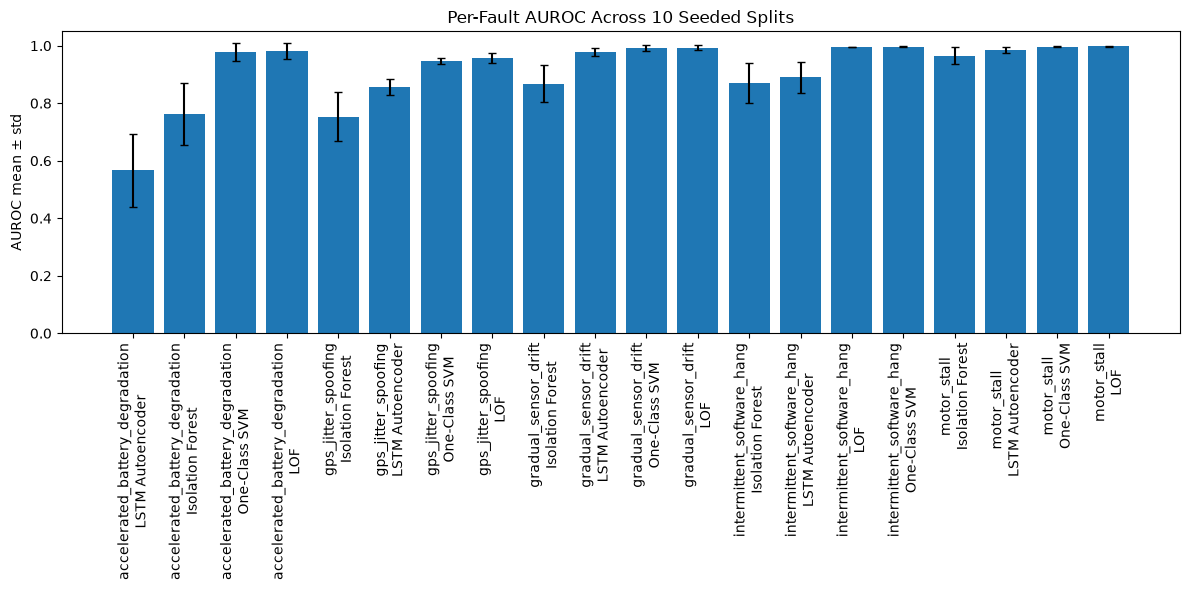

In [12]:
# AUROC visualization.
plot_df = summary_df.copy()
plot_df = plot_df[plot_df["scope"] != "all_faults"].sort_values(["scope", "auroc_mean"])

fig, ax = plt.subplots(figsize=(12, 6))
x_labels = plot_df["scope"] + "\n" + plot_df["method"]
ax.bar(np.arange(len(plot_df)), plot_df["auroc_mean"], yerr=plot_df["auroc_std"], capsize=3)
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(x_labels, rotation=90)
ax.set_ylim(0, 1.05)
ax.set_ylabel("AUROC mean ± std")
ax.set_title("Per-Fault AUROC Across 10 Seeded Splits")
plt.tight_layout()
plt.show()


## 9. Paired Wilcoxon Signed-Rank Test on AUROC Differences

For each fault scope, the test compares paired AUROC values across the same 10 split seeds. This is a paired design because each method sees the same injected faults and the same held-out blocks for a given split seed.

The table reports:

- `method_a`
- `method_b`
- `mean_auroc_diff = mean(AUROC_A - AUROC_B)`
- Wilcoxon signed-rank statistic
- two-sided p-value


In [13]:
def safe_wilcoxon(a, b):
    # Run paired Wilcoxon signed-rank test safely.
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    valid = np.isfinite(a) & np.isfinite(b)
    a = a[valid]
    b = b[valid]

    if len(a) < 2:
        return np.nan, np.nan, len(a)

    diff = a - b

    if np.allclose(diff, 0.0):
        return 0.0, 1.0, len(a)

    try:
        stat, pvalue = wilcoxon(diff, zero_method="wilcox", alternative="two-sided")
        return float(stat), float(pvalue), len(a)
    except ValueError:
        return np.nan, np.nan, len(a)


wilcoxon_rows = []
methods = sorted(metrics_df["method"].dropna().unique())
scopes = sorted(metrics_df["scope"].dropna().unique())

for scope in scopes:
    scope_df = metrics_df[metrics_df["scope"] == scope]

    for i, method_a in enumerate(methods):
        for method_b in methods[i + 1:]:
            a_df = scope_df[scope_df["method"] == method_a].sort_values("split_seed")
            b_df = scope_df[scope_df["method"] == method_b].sort_values("split_seed")
            merged = a_df[["split_seed", "auroc"]].merge(
                b_df[["split_seed", "auroc"]],
                on="split_seed",
                suffixes=("_a", "_b"),
            )
            a = merged["auroc_a"].to_numpy()
            b = merged["auroc_b"].to_numpy()

            stat, pvalue, n_pairs = safe_wilcoxon(a, b)
            diff = a - b
            diff = diff[np.isfinite(diff)]

            wilcoxon_rows.append({
                "scope": scope,
                "method_a": method_a,
                "method_b": method_b,
                "mean_auroc_diff_a_minus_b": float(np.nanmean(diff)) if len(diff) else np.nan,
                "wilcoxon_statistic": stat,
                "p_value_two_sided": pvalue,
                "n_pairs": n_pairs,
            })

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
wilcoxon_path = RESULTS_DIR / "w04_wilcoxon_auroc_pairwise.csv"
wilcoxon_df.to_csv(wilcoxon_path, index=False)

print("Saved:", wilcoxon_path)
display(wilcoxon_df.sort_values(["scope", "p_value_two_sided", "method_a", "method_b"]).head(50))


Saved: ../results/w04_anomaly_benchmark/w04_wilcoxon_auroc_pairwise.csv


,scope,method_a,method_b,mean_auroc_diff_a_minus_b,wilcoxon_statistic,p_value_two_sided,n_pairs
0,accelerated_battery_degradation,Isolation Forest,LOF,-0.218308,0.0,0.001953,10
1,accelerated_battery_degradation,Isolation Forest,LSTM Autoencoder,0.197033,0.0,0.001953,10
2,accelerated_battery_degradation,Isolation Forest,One-Class SVM,-0.215574,0.0,0.001953,10
3,accelerated_battery_degradation,LOF,LSTM Autoencoder,0.415341,0.0,0.001953,10
5,accelerated_battery_degradation,LSTM Autoencoder,One-Class SVM,-0.412606,0.0,0.001953,10
4,accelerated_battery_degradation,LOF,One-Class SVM,0.002734,1.0,0.003906,10
6,all_faults,Isolation Forest,LOF,-0.141178,0.0,0.001953,10
8,all_faults,Isolation Forest,One-Class SVM,-0.137918,0.0,0.001953,10
9,all_faults,LOF,LSTM Autoencoder,0.137207,0.0,0.001953,10
11,all_faults,LSTM Autoencoder,One-Class SVM,-0.133947,0.0,0.001953,10


## 10. Fault Injection Audit Tables

These tables document the injected events and confirm that all injected faults stayed inside held-out test blocks.


In [14]:
fault_counts = (
    fault_ledger_df
    .groupby(["split_seed", "fault_type"])
    .size()
    .reset_index(name="events")
    .pivot(index="split_seed", columns="fault_type", values="events")
    .fillna(0)
    .astype(int)
)

display(fault_counts)

duration_summary = (
    fault_ledger_df
    .groupby("fault_type")
    .agg(
        events=("fault_id", "count"),
        mean_duration_s=("duration_s", "mean"),
        std_duration_s=("duration_s", "std"),
        mean_severity=("severity", "mean"),
        std_severity=("severity", "std"),
    )
    .reset_index()
)

display(duration_summary)


fault_type,accelerated_battery_degradation,gps_jitter_spoofing,gradual_sensor_drift,intermittent_software_hang,motor_stall
split_seed,,,,,
20260400,3,3,3,3,3
20260401,3,3,3,3,3
20260402,3,3,3,3,3
20260403,3,3,3,3,3
20260404,3,3,3,3,3
20260405,3,3,3,3,3
20260406,3,3,3,3,3
20260407,3,3,3,3,3
20260408,3,3,3,3,3


,fault_type,events,mean_duration_s,std_duration_s,mean_severity,std_severity
0,accelerated_battery_degradation,30,618.466667,205.009122,0.790514,0.096056
1,gps_jitter_spoofing,30,581.933333,196.682474,0.816346,0.114565
2,gradual_sensor_drift,30,588.566667,217.956763,0.817987,0.134275
3,intermittent_software_hang,30,528.400000,172.706368,0.821784,0.114785
4,motor_stall,30,587.566667,194.989599,0.801560,0.112174


## 11. Benchmark Notes and Operating Considerations

The benchmark should be read as an evaluation of controlled synthetic faults under a fixed, leakage-controlled protocol. The strongest method is not necessarily the one with the highest single AUROC in one split. A more reliable assessment should consider:

- consistency across the 10 seeded splits,
- per-fault performance rather than only aggregate performance,
- precision and recall tradeoffs at the selected operating threshold,
- robustness to gradual faults versus abrupt faults,
- statistical evidence from the paired Wilcoxon signed-rank tests,
- operational interpretability for Rover-style fleet monitoring.

Typical patterns to watch for:

- Abrupt faults such as motor stall and GPS jitter may be easier for tree-based or density-based methods.
- Gradual drift and intermittent software hang may require temporal context and may benefit from sequence models.
- A method with strong AUROC can still have weak precision at the chosen threshold, so threshold behavior should be reviewed alongside ranking quality.
- A method that performs slightly worse on average may still be preferred if it is more stable, easier to explain, or less sensitive to benign telemetry variation.

These notes are included to keep the benchmark results grounded in practical deployment review rather than single-run model ranking.

In [15]:
# Final export preview.
print("Generated artifacts:")
for path in sorted(RESULTS_DIR.glob("*.csv")):
    print(" -", path)

print("\nBenchmark complete.")


Generated artifacts:
 - ../results/w04_anomaly_benchmark/w04_fault_injection_ledger.csv
 - ../results/w04_anomaly_benchmark/w04_metrics_per_split.csv
 - ../results/w04_anomaly_benchmark/w04_metrics_summary_mean_std.csv
 - ../results/w04_anomaly_benchmark/w04_wilcoxon_auroc_pairwise.csv

Benchmark complete.
